# Persistence regression figures

- **Figure 3** — Main text (6 panels): bubble decomposition, scatter regressions, per-tree R²/p/β
- **S-PersistenceBTintro** — Same as Fig 3 B–F but response = BT/intro
- **S-PersistenceLOO** — Leave-one-out robustness for volume and density

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats as sp_stats

for font in ['Arial', 'Helvetica', 'DejaVu Sans']:
    try:
        matplotlib.font_manager.findfont(font, fallback_to_default=False)
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = [font]
        break
    except ValueError:
        continue

plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

PROJ_ROOT = Path('../..').resolve()
PAPER_DIR = PROJ_ROOT / 'paper' / 'final'
FINAL_DIR = PAPER_DIR
FIG_DIR = FINAL_DIR / 'figures'

BEAST_DIR = PAPER_DIR / 'analysis/beast'
_CORR2_DIR = BEAST_DIR / 'phylogeography/correlateSet2e'
TREE_FILE = _CORR2_DIR / 'timeinhomogeneous_correlateSet2enforced_weeklyEpochs_3era_3rateScalar.burninRemovedResampled.trees'
JUMP_FILE = _CORR2_DIR / 'timeinhomogeneous_correlateSet2enforced_weeklyEpochs_3era_3rateScalar.jumpHistory.log'

TREE_STATE_COLORS = {
    'CA': '#ff7f00', 'TX': '#e41a1c', 'ID': '#7b3294', 'CO': '#2166ac',
    'IA': '#1b9e77', 'MN': '#00838f', 'MI': '#8c6d31', 'OH': '#c51b7d',
    'NM': '#b2abd2', 'WY': '#a6d854', 'SD': '#fc8d62', 'KS': '#ffd92f',
    'UT': '#e5c494', 'NE': '#b3b3b3', 'OK': '#d9d9d9', 'NC': '#66c2a5',
}

COV_7 = [
    ('mean_internal_volume', 'Internal\nvolume'),
    ('mean_internal_density', 'Internal\ndensity'),
    ('n_dairy_counties', 'Dairy\ncounties'),
    ('mean_external_in_edges', 'Incoming\nroutes'),
    ('mean_external_in_volume', 'Incoming\nvolume'),
    ('herd_density', 'Herd\ndensity'),
    ('replacement_ratio', 'Replacement\nratio'),
]


def hpd(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = int(np.argmin(widths))
    return sorted_samples[best], sorted_samples[best + interval_size - 1]


def standardize(x):
    sd = x.std()
    if sd == 0:
        return np.zeros_like(x)
    return (x - x.mean()) / sd

## Load data

In [2]:
bt_df = pd.read_csv(FIG_DIR / 'persistence_branch_times_225trees.csv')
pred = pd.read_csv(FINAL_DIR / 'data/covariates/network_predictors_1000nets_16states.csv')

# Merge predictors onto branch time data
df = bt_df.merge(pred, on='state', how='left')

trees = sorted(df['tree'].unique())
n_trees = len(trees)
states = sorted(df['state'].unique())
n_states = len(states)
print(f'{n_trees} trees, {n_states} states')
print(f'Predictors: {[c for c, _ in COV_7]}')

225 trees, 16 states
Predictors: ['mean_internal_volume', 'mean_internal_density', 'n_dairy_counties', 'mean_external_in_edges', 'mean_external_in_volume', 'herd_density', 'replacement_ratio']


## Per-tree regression engine

In [3]:
def run_per_tree_regressions(df, response_col, pred_cols, exclude_states=None):
    """Run univariate OLS per tree per predictor.
    Returns dict with arrays of shape (n_trees, n_preds) for r2, p, beta."""
    trees = sorted(df['tree'].unique())
    n_preds = len(pred_cols)
    r2_arr = np.zeros((len(trees), n_preds))
    p_arr = np.ones((len(trees), n_preds))
    beta_arr = np.zeros((len(trees), n_preds))

    for ti, tree in enumerate(trees):
        td = df[df['tree'] == tree].copy()
        if exclude_states:
            td = td[~td['state'].isin(exclude_states)]
        if len(td) < 5:
            continue

        y = np.log(np.maximum(td[response_col].values, 1e-6))
        n = len(td)

        for pi, col in enumerate(pred_cols):
            x_raw = np.log(np.maximum(td[col].values.astype(float), 1e-10))
            x_z = standardize(x_raw)
            slope, intercept, r, p, se = sp_stats.linregress(x_z, y)
            r2_arr[ti, pi] = r ** 2
            p_arr[ti, pi] = p
            beta_arr[ti, pi] = slope

    return {'r2': r2_arr, 'p': p_arr, 'beta': beta_arr, 'trees': trees}


pred_cols = [c for c, _ in COV_7]
pred_labels = [l for _, l in COV_7]

print('Running regressions: response = log(branch_time)...')
res_bt = run_per_tree_regressions(df, 'branch_time', pred_cols)
print('Running regressions: response = log(bt_per_intro)...')
res_bpi = run_per_tree_regressions(df, 'bt_per_intro', pred_cols)
print('Done.')

# Summary
for name, res in [('Total BT', res_bt), ('BT/intro', res_bpi)]:
    print(f'\n=== {name} ===')
    for pi, (col, label) in enumerate(COV_7):
        r2 = res['r2'][:, pi]
        p = res['p'][:, pi]
        beta = res['beta'][:, pi]
        r2_lo, r2_hi = hpd(r2)
        pct_sig = np.mean(p < 0.05) * 100
        print(f'  {col:30s}: median R²={np.median(r2):.3f} [{r2_lo:.3f},{r2_hi:.3f}]  '
              f'{pct_sig:.0f}% sig  median β={np.median(beta):.3f}')

Running regressions: response = log(branch_time)...
Running regressions: response = log(bt_per_intro)...
Done.

=== Total BT ===
  mean_internal_volume          : median R²=0.516 [0.486,0.543]  100% sig  median β=1.234
  mean_internal_density         : median R²=0.465 [0.437,0.487]  100% sig  median β=1.172
  n_dairy_counties              : median R²=0.001 [0.000,0.002]  0% sig  median β=-0.049
  mean_external_in_edges        : median R²=0.196 [0.172,0.212]  0% sig  median β=0.762
  mean_external_in_volume       : median R²=0.217 [0.194,0.239]  0% sig  median β=0.799
  herd_density                  : median R²=0.030 [0.022,0.039]  0% sig  median β=0.297
  replacement_ratio             : median R²=0.020 [0.011,0.027]  0% sig  median β=-0.244

=== BT/intro ===
  mean_internal_volume          : median R²=0.328 [0.268,0.400]  100% sig  median β=0.906
  mean_internal_density         : median R²=0.296 [0.237,0.386]  94% sig  median β=0.866
  n_dairy_counties              : median R²=0.036 [0

## Variance decomposition

In [4]:
# log(BT) = log(intros) + log(BT/intro)
# Var(log BT) = Var(log intros) + Var(log BT/intro) + 2*Cov(...)
var_decomp = []
for tree in trees:
    td = df[df['tree'] == tree]
    log_bt = np.log(np.maximum(td['branch_time'].values, 1e-6))
    log_intros = np.log(np.maximum(td['n_introductions'].values, 1e-6))
    log_bpi = np.log(np.maximum(td['bt_per_intro'].values, 1e-6))

    var_bt = np.var(log_bt, ddof=1)
    var_intros = np.var(log_intros, ddof=1)
    var_bpi = np.var(log_bpi, ddof=1)
    cov_term = 2 * np.cov(log_intros, log_bpi)[0, 1]

    if var_bt > 0:
        var_decomp.append({
            'frac_duration': var_bpi / var_bt,
            'frac_intros': var_intros / var_bt,
            'frac_cov': cov_term / var_bt,
        })

vd = pd.DataFrame(var_decomp)
print(f'Variance decomposition (median across {len(vd)} trees):')
print(f'  Duration (BT/intro): {np.median(vd["frac_duration"])*100:.1f}%')
print(f'  Introductions:       {np.median(vd["frac_intros"])*100:.1f}%')
print(f'  Covariance:          {np.median(vd["frac_cov"])*100:.1f}%')

Variance decomposition (median across 225 trees):
  Duration (BT/intro): 84.8%
  Introductions:       27.2%
  Covariance:          -12.3%


## Figure 3

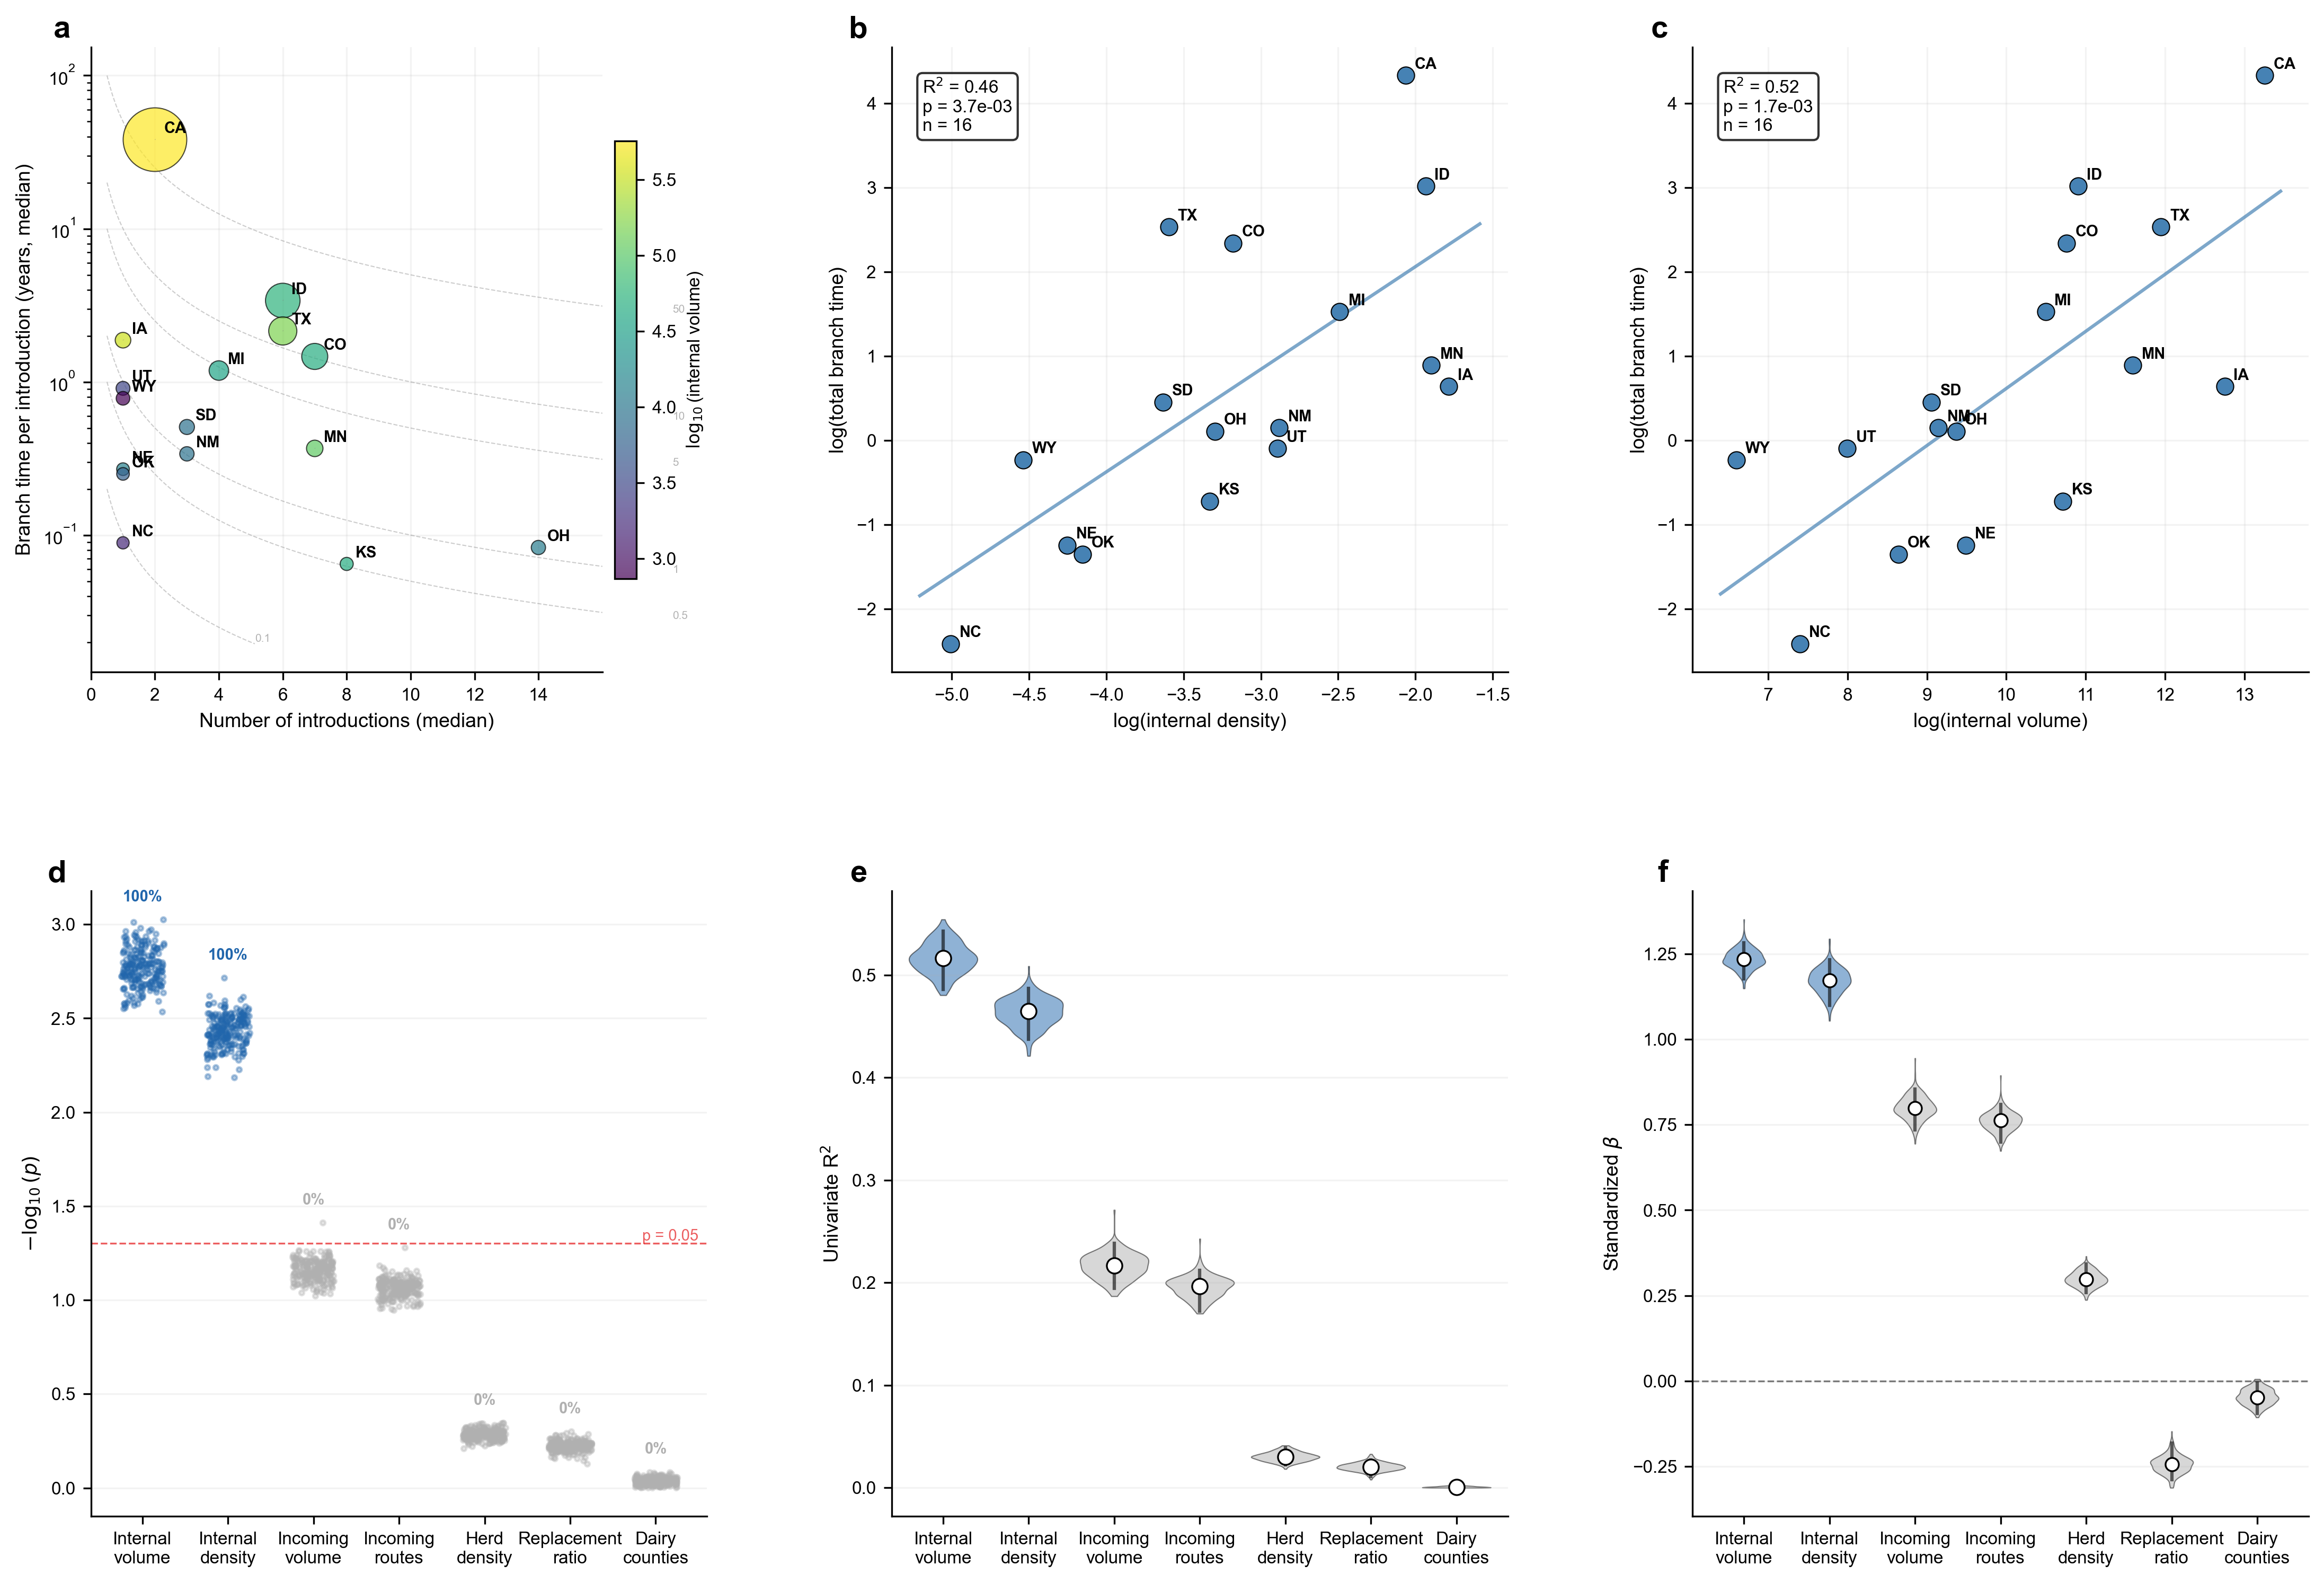

In [5]:
# State-level medians for panels A-C
state_med = df.groupby('state').agg(
    bt_median=('branch_time', 'median'),
    intros_median=('n_introductions', 'median'),
    bpi_median=('bt_per_intro', 'median'),
).reset_index()
state_med = state_med.merge(pred, on='state', how='left')

# Order predictors by median R² descending for panels D-F
median_r2 = np.array([np.median(res_bt['r2'][:, pi]) for pi in range(len(pred_cols))])
pred_order = np.argsort(-median_r2)
ordered_labels = [pred_labels[i] for i in pred_order]
ordered_cols = [pred_cols[i] for i in pred_order]
pct_sig = [np.mean(res_bt['p'][:, i] < 0.05) * 100 for i in pred_order]

COL_SIG = '#2166ac'
COL_NONSIG = '#b0b0b0'
sig_colors = [COL_SIG if p >= 90 else COL_NONSIG for p in pct_sig]

st_names = state_med['state'].values

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.30)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])
ax_e = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_f = fig.add_subplot(gs[1, 2])

# ---- Panel A: Bubble decomposition ----
ax_a.text(-0.04, 1.05, 'a', transform=ax_a.transAxes, fontsize=14,
          fontweight='bold', va='top', ha='right')

n_intros = state_med['intros_median'].values
time_per = state_med['bpi_median'].values
total_bt = state_med['bt_median'].values
vol = state_med['mean_internal_volume'].values

sizes = (total_bt / total_bt.max()) * 800 + 30
sc = ax_a.scatter(n_intros, time_per, s=sizes, c=np.log10(vol + 1),
                  cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5, zorder=5)

for i, s in enumerate(st_names):
    ax_a.annotate(s, (n_intros[i], time_per[i]),
                  xytext=(4, 3), textcoords='offset points',
                  fontsize=7, fontweight='bold', ha='left', zorder=10,
                  arrowprops=dict(arrowstyle='-', color='grey', lw=0.3, alpha=0.4))

for bt_ref in [0.1, 0.5, 1, 5, 10, 50]:
    x_ref = np.linspace(0.5, max(n_intros) * 1.3, 200)
    y_ref = bt_ref / x_ref
    mask = (y_ref >= min(time_per) * 0.3) & (y_ref <= max(time_per) * 3)
    if mask.any():
        ax_a.plot(x_ref[mask], y_ref[mask], '--', color='grey', lw=0.5, alpha=0.4)
        valid_x = x_ref[mask]
        valid_y = y_ref[mask]
        ax_a.text(valid_x[-1], valid_y[-1], f'{bt_ref}', fontsize=5,
                  color='grey', alpha=0.6, ha='left', va='bottom')

cbar = fig.colorbar(sc, ax=ax_a, shrink=0.7, pad=0.02)
cbar.set_label(r'$\log_{10}$(internal volume)', fontsize=8)


ax_a.set_xlabel('Number of introductions (median)', fontsize=9)
ax_a.set_ylabel('Branch time per introduction (years, median)', fontsize=9)
ax_a.set_yscale('log')
ax_a.set_xlim(0, 16)
ax_a.set_xticks(range(0, 16, 2))
ax_a.grid(True, alpha=0.15)
for sp in ['top', 'right']:
    ax_a.spines[sp].set_visible(False)

# ---- Panels B, C: Scatter regressions (single color, bold labels) ----
def draw_scatter(ax, x_col, x_label, panel_label):
    ax.text(-0.04, 1.05, panel_label, transform=ax.transAxes, fontsize=14,
            fontweight='bold', va='top', ha='right')
    x = np.log(state_med[x_col].values)
    y = np.log(state_med['bt_median'].values)
    slope, intercept, r, p, se = sp_stats.linregress(x, y)
    x_fit = np.linspace(x.min() - 0.2, x.max() + 0.2, 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, '-', color='steelblue', lw=1.5, alpha=0.7, zorder=2)
    ax.scatter(x, y, s=60, color='steelblue', edgecolor='black', lw=0.5, zorder=5)
    for i, s in enumerate(st_names):
        ax.annotate(s, (x[i], y[i]), xytext=(4, 3), textcoords='offset points',
                    fontsize=7, fontweight='bold', ha='left', zorder=10)
    ax.text(0.05, 0.95, f'R$^2$ = {r**2:.2f}\np = {p:.1e}\nn = {n_states}',
            transform=ax.transAxes, fontsize=8, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_xlabel(f'log({x_label})', fontsize=9)
    ax.set_ylabel('log(total branch time)', fontsize=9)
    ax.grid(True, alpha=0.15)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

draw_scatter(ax_b, 'mean_internal_density', 'internal density', 'b')
draw_scatter(ax_c, 'mean_internal_volume', 'internal volume', 'c')

# ---- Panel E: R² violins ----
ax_d.text(-0.04, 1.05, 'e', transform=ax_d.transAxes, fontsize=14,
          fontweight='bold', va='top', ha='right')

violin_data_r2 = [res_bt['r2'][:, i] for i in pred_order]
positions = list(range(len(pred_order)))
parts = ax_d.violinplot(violin_data_r2, positions=positions, showextrema=False,
                        showmedians=False, showmeans=False, widths=0.8)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(sig_colors[i])
    pc.set_alpha(0.5)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

for i, vals in enumerate(violin_data_r2):
    med = np.median(vals)
    lo, hi = hpd(vals)
    ax_d.plot([i, i], [lo, hi], color='black', lw=1.5, alpha=0.6, zorder=3)
    ax_d.plot(i, med, 'o', color='white', markersize=7, zorder=5,
              markeredgecolor='black', markeredgewidth=0.8)

ax_d.set_xlim(-0.6, len(positions) - 0.4)
ax_d.set_xticks(positions)
ax_d.set_xticklabels(ordered_labels, fontsize=8)
ax_d.set_ylabel('Univariate R$^2$', fontsize=9)
ax_d.grid(True, alpha=0.15, axis='y')
for sp in ['top', 'right']:
    ax_d.spines[sp].set_visible(False)

# ---- Panel E: -log10(p) strip with % significant just above max dot ----
ax_e.text(-0.04, 1.05, 'd', transform=ax_e.transAxes, fontsize=14,
          fontweight='bold', va='top', ha='right')

for i, pi_orig in enumerate(pred_order):
    p_vals = res_bt['p'][:, pi_orig]
    neg_log_p = -np.log10(np.maximum(p_vals, 1e-20))
    color = sig_colors[i]
    ax_e.scatter(np.full_like(neg_log_p, i) + np.random.uniform(-0.25, 0.25, len(neg_log_p)),
                 neg_log_p, s=5, alpha=0.35, color=color, zorder=3, rasterized=True)
    max_y = np.max(neg_log_p)
    pct = pct_sig[i]
    ax_e.text(i, max_y + 0.08, f'{pct:.0f}%', ha='center', va='bottom',
              fontsize=7, fontweight='bold', color=color, zorder=10)

ax_e.axhline(-np.log10(0.05), color='#e41a1c', ls='--', lw=0.8, alpha=0.7)
ax_e.text(len(pred_order) - 0.5, -np.log10(0.05), 'p = 0.05', fontsize=7,
          va='bottom', ha='right', alpha=0.7, color='#e41a1c')
ax_e.set_xlim(-0.6, len(positions) - 0.4)
ax_e.set_xticks(positions)
ax_e.set_xticklabels(ordered_labels, fontsize=8)
ax_e.set_ylabel(r'$-\log_{10}(p)$', fontsize=9)
ax_e.grid(True, alpha=0.15, axis='y')
for sp in ['top', 'right']:
    ax_e.spines[sp].set_visible(False)

# ---- Panel F: β violins ----
ax_f.text(-0.04, 1.05, 'f', transform=ax_f.transAxes, fontsize=14,
          fontweight='bold', va='top', ha='right')

violin_data_beta = [res_bt['beta'][:, i] for i in pred_order]
parts_f = ax_f.violinplot(violin_data_beta, positions=positions, showextrema=False,
                          showmedians=False, showmeans=False)
for i, pc in enumerate(parts_f['bodies']):
    pc.set_facecolor(sig_colors[i])
    pc.set_alpha(0.5)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

for i, vals in enumerate(violin_data_beta):
    med = np.median(vals)
    lo, hi = hpd(vals)
    ax_f.plot([i, i], [lo, hi], color='black', lw=1.5, alpha=0.6, zorder=3)
    ax_f.plot(i, med, 'o', color='white', markersize=6, zorder=5,
              markeredgecolor='black', markeredgewidth=0.8)

ax_f.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
ax_f.set_xlim(-0.6, len(positions) - 0.4)
ax_f.set_xticks(positions)
ax_f.set_xticklabels(ordered_labels, fontsize=8)
ax_f.set_ylabel(r'Standardized $\beta$', fontsize=9)
ax_f.grid(True, alpha=0.15, axis='y')
for sp in ['top', 'right']:
    ax_f.spines[sp].set_visible(False)

# fig.savefig(FIG_DIR / 'fig_3.png', dpi=300, bbox_inches='tight')
# fig.savefig(FIG_DIR / 'fig_3.pdf', bbox_inches='tight')
# print(f'Saved fig_3 to {FIG_DIR}')
plt.show()

## S-PersistenceBTintro

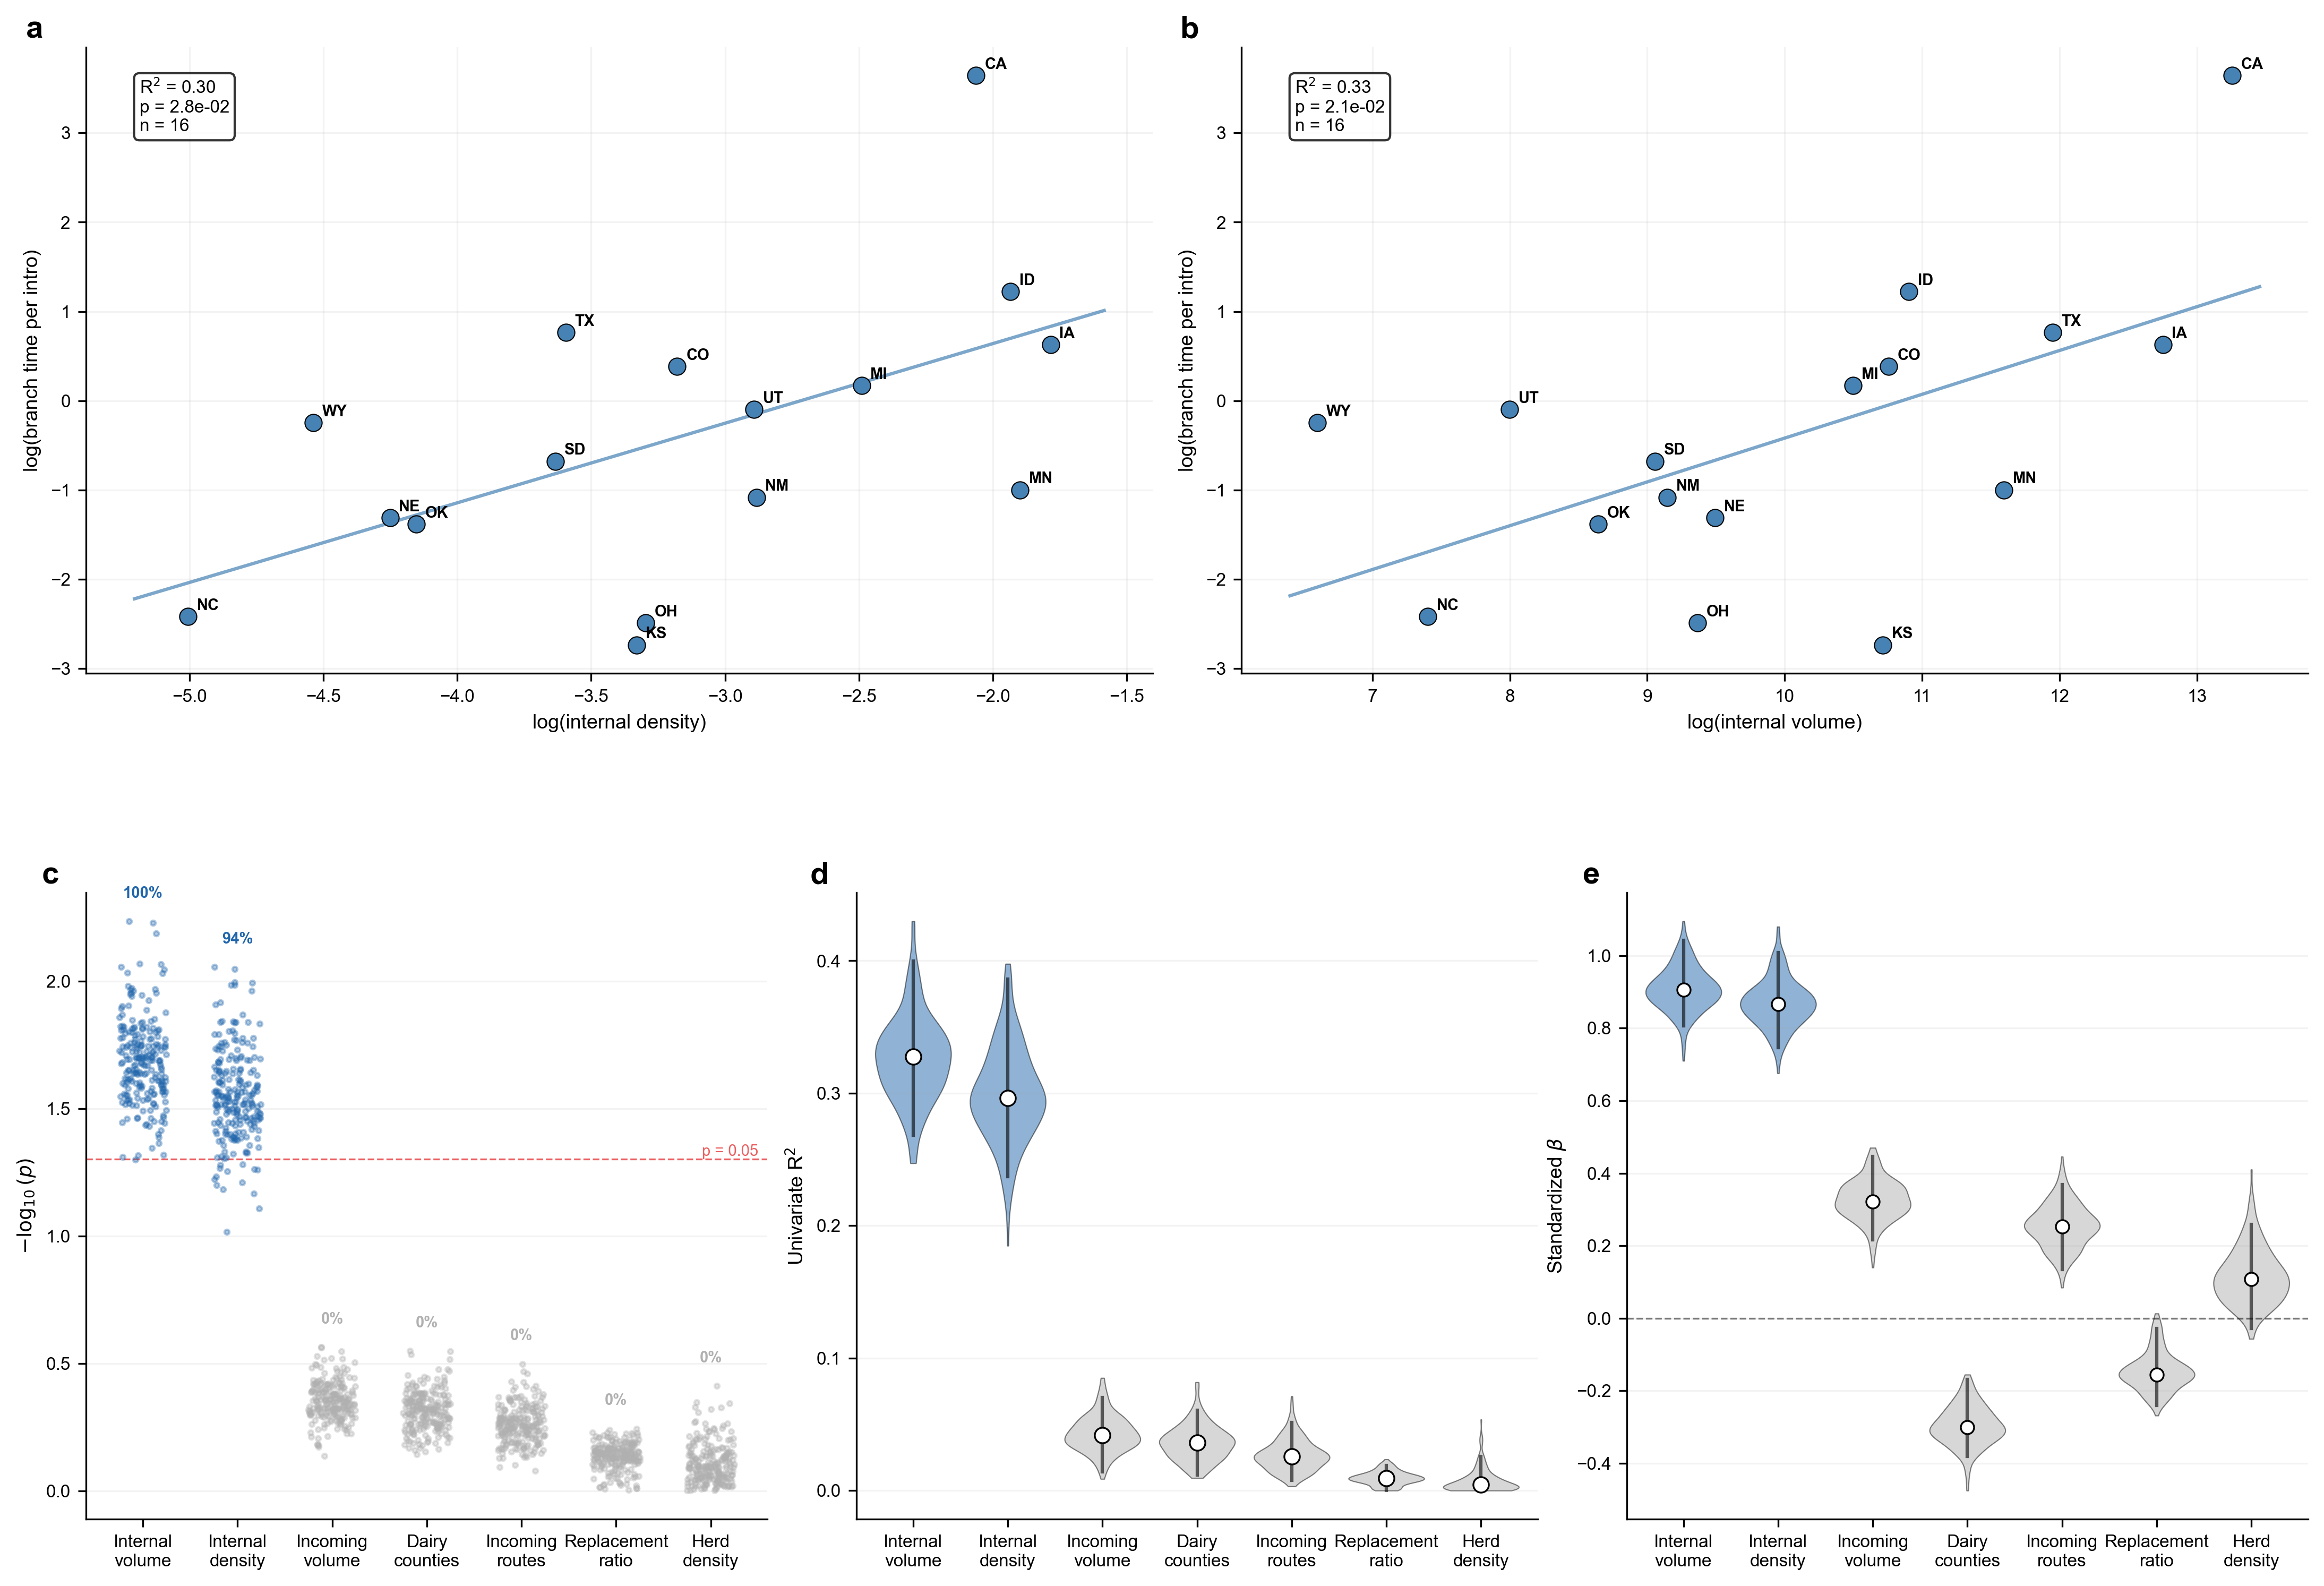

In [6]:
# Order by median R² for BT/intro response
median_r2_bpi = np.array([np.median(res_bpi['r2'][:, pi]) for pi in range(len(pred_cols))])
pred_order_bpi = np.argsort(-median_r2_bpi)
ordered_labels_bpi = [pred_labels[i] for i in pred_order_bpi]
pct_sig_bpi = [np.mean(res_bpi['p'][:, i] < 0.05) * 100 for i in pred_order_bpi]
sig_colors_bpi = [COL_SIG if p >= 90 else COL_NONSIG for p in pct_sig_bpi]

fig2 = plt.figure(figsize=(18, 12))
gs2 = fig2.add_gridspec(2, 6, hspace=0.35, wspace=0.30)

ax_ba = fig2.add_subplot(gs2[0, 0:3])
ax_bb = fig2.add_subplot(gs2[0, 3:6])
ax_be = fig2.add_subplot(gs2[1, 0:2])
ax_bd = fig2.add_subplot(gs2[1, 2:4])
ax_bf = fig2.add_subplot(gs2[1, 4:6])

# ---- Scatter: density vs BT/intro (single color, bold labels) ----
def draw_scatter_bpi(ax, x_col, x_label, panel_label):
    ax.text(-0.04, 1.05, panel_label, transform=ax.transAxes, fontsize=14,
            fontweight='bold', va='top', ha='right')
    x = np.log(state_med[x_col].values)
    y = np.log(state_med['bpi_median'].values)
    slope, intercept, r, p, se = sp_stats.linregress(x, y)
    x_fit = np.linspace(x.min() - 0.2, x.max() + 0.2, 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, '-', color='steelblue', lw=1.5, alpha=0.7, zorder=2)
    ax.scatter(x, y, s=60, color='steelblue', edgecolor='black', lw=0.5, zorder=5)
    for i, s in enumerate(st_names):
        ax.annotate(s, (x[i], y[i]), xytext=(4, 3), textcoords='offset points',
                    fontsize=7, fontweight='bold', ha='left', zorder=10)
    ax.text(0.05, 0.95, f'R$^2$ = {r**2:.2f}\np = {p:.1e}\nn = {n_states}',
            transform=ax.transAxes, fontsize=8, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_xlabel(f'log({x_label})', fontsize=9)
    ax.set_ylabel('log(branch time per intro)', fontsize=9)
    ax.grid(True, alpha=0.15)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

draw_scatter_bpi(ax_ba, 'mean_internal_density', 'internal density', 'a')
draw_scatter_bpi(ax_bb, 'mean_internal_volume', 'internal volume', 'b')

# ---- R² violins ----
ax_bd.text(-0.04, 1.05, 'd', transform=ax_bd.transAxes, fontsize=14,
           fontweight='bold', va='top', ha='right')
positions_bpi = list(range(len(pred_order_bpi)))
violin_r2_bpi = [res_bpi['r2'][:, i] for i in pred_order_bpi]
parts_bd = ax_bd.violinplot(violin_r2_bpi, positions=positions_bpi, showextrema=False,
                            showmedians=False, showmeans=False, widths=0.8)
for i, pc in enumerate(parts_bd['bodies']):
    pc.set_facecolor(sig_colors_bpi[i])
    pc.set_alpha(0.5)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)
for i, vals in enumerate(violin_r2_bpi):
    med = np.median(vals)
    lo, hi = hpd(vals)
    ax_bd.plot([i, i], [lo, hi], color='black', lw=1.5, alpha=0.6, zorder=3)
    ax_bd.plot(i, med, 'o', color='white', markersize=7, zorder=5,
               markeredgecolor='black', markeredgewidth=0.8)
ax_bd.set_xlim(-0.6, len(positions_bpi) - 0.4)
ax_bd.set_xticks(positions_bpi)
ax_bd.set_xticklabels(ordered_labels_bpi, fontsize=8)
ax_bd.set_ylabel('Univariate R$^2$', fontsize=9)
ax_bd.grid(True, alpha=0.15, axis='y')
for sp in ['top', 'right']:
    ax_bd.spines[sp].set_visible(False)

# ---- -log10(p) strip with % significant just above max dot ----
ax_be.text(-0.04, 1.05, 'c', transform=ax_be.transAxes, fontsize=14,
           fontweight='bold', va='top', ha='right')
for i, pi_orig in enumerate(pred_order_bpi):
    p_vals = res_bpi['p'][:, pi_orig]
    neg_log_p = -np.log10(np.maximum(p_vals, 1e-20))
    color = sig_colors_bpi[i]
    ax_be.scatter(np.full_like(neg_log_p, i) + np.random.uniform(-0.25, 0.25, len(neg_log_p)),
                  neg_log_p, s=5, alpha=0.35, color=color, zorder=3, rasterized=True)
    max_y = np.max(neg_log_p)
    pct = pct_sig_bpi[i]
    ax_be.text(i, max_y + 0.08, f'{pct:.0f}%', ha='center', va='bottom',
               fontsize=7, fontweight='bold', color=color, zorder=10)
ax_be.axhline(-np.log10(0.05), color='#e41a1c', ls='--', lw=0.8, alpha=0.7)
ax_be.text(len(pred_order_bpi) - 0.5, -np.log10(0.05), 'p = 0.05', fontsize=7,
           va='bottom', ha='right', alpha=0.7, color='#e41a1c')
ax_be.set_xlim(-0.6, len(positions_bpi) - 0.4)
ax_be.set_xticks(positions_bpi)
ax_be.set_xticklabels(ordered_labels_bpi, fontsize=8)
ax_be.set_ylabel(r'$-\log_{10}(p)$', fontsize=9)
ax_be.grid(True, alpha=0.15, axis='y')
for sp in ['top', 'right']:
    ax_be.spines[sp].set_visible(False)

# ---- β violins ----
ax_bf.text(-0.04, 1.05, 'e', transform=ax_bf.transAxes, fontsize=14,
           fontweight='bold', va='top', ha='right')
violin_beta_bpi = [res_bpi['beta'][:, i] for i in pred_order_bpi]
parts_bf = ax_bf.violinplot(violin_beta_bpi, positions=positions_bpi, showextrema=False,
                            showmedians=False, showmeans=False, widths=0.8)
for i, pc in enumerate(parts_bf['bodies']):
    pc.set_facecolor(sig_colors_bpi[i])
    pc.set_alpha(0.5)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)
for i, vals in enumerate(violin_beta_bpi):
    med = np.median(vals)
    lo, hi = hpd(vals)
    ax_bf.plot([i, i], [lo, hi], color='black', lw=1.5, alpha=0.6, zorder=3)
    ax_bf.plot(i, med, 'o', color='white', markersize=6, zorder=5,
               markeredgecolor='black', markeredgewidth=0.8)
ax_bf.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
ax_bf.set_xlim(-0.6, len(positions_bpi) - 0.4)
ax_bf.set_xticks(positions_bpi)
ax_bf.set_xticklabels(ordered_labels_bpi, fontsize=8)
ax_bf.set_ylabel(r'Standardized $\beta$', fontsize=9)
ax_bf.grid(True, alpha=0.15, axis='y')
for sp in ['top', 'right']:
    ax_bf.spines[sp].set_visible(False)



# fig2.savefig(FIG_DIR / 'S_PersistenceBTintro.png', dpi=300, bbox_inches='tight')
# fig2.savefig(FIG_DIR / 'S_PersistenceBTintro.pdf', bbox_inches='tight')
# print(f'Saved S_PersistenceBTintro to {FIG_DIR}')
plt.show()